# Подгружаем необходимые модули

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import torch
import torch.nn as nn
import tqdm

Проверяем, доступна ли gpu

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Класс с данными.

Атрибуты класса: минимальные и максимальные значения расчетной области, параметры задачи -- коэффициенты уравнения, кол-во точек.

В нем необходимо создать сетку, на которой будет рассчитываться задача и функцию **calculate_solution**, в которой будет создаваться атрибут **self.solution** с аналитическим решением:

# $u(x,t)=\exp{\left(\frac{-n^2\pi^2\alpha t}{m^2}\right) \sin \left( \frac{n\pi
			x}{m}\right)}.$

In [12]:
class Dataset:

    def __init__(self, alpha=0.3, # аргументы по умолчанию,
                 #которые будут равны этим значениям, если их не передать в функцию
                 xmin=0, tmin=0,
                 xmax=1, tmax=1,
                 Nx=100, Nt=50,
                 m=1, n=1):
        self.m=1
        self.n =1
        self.alpha=0.3
        self.tmin=0
        self.xmin=0
        self.tmax=1
        self.xmax=1

        self.x=np.linspace(xmin, xmax, 100)
        self.t=np.linspace(tmin, tmax, 50)
        self.x, self.t = np.meshgrid(self.x, self.t)
        self.calculate_solution()

    def calculate_solution(self):
        self.solution= np.exp(-self.n**2*np.pi*self.alpha*self.t/self.m**2)*np.sin(self.n*np.pi*self.x/self.m)#аналитическое решение



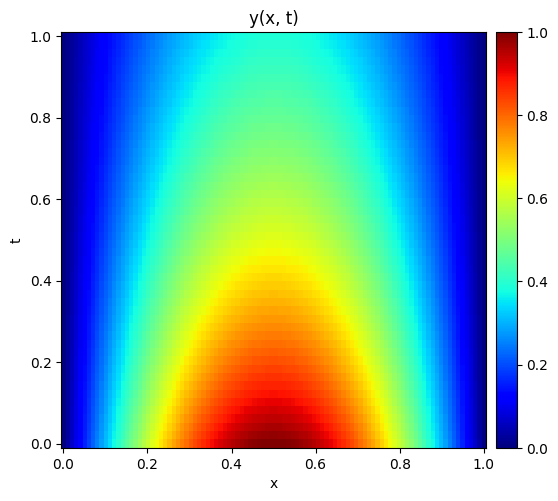

In [17]:
#создать датасет с m=1, n=1
data=Dataset(0.3, 0, 0, 1, 1, 100, 50, 1, 1)

#нарисовать график с аналитическим решением
fig, ax = plt.subplots(figsize=(6.6, 5.4))
pcm=ax.pcolormesh(data.x, data.t, data.solution, cmap="jet", shading="auto", vmin=0.0, vmax=1.0)
cb=fig.colorbar(pcm, ax=ax, pad=0.02)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('y(x, t)')

plt.show()

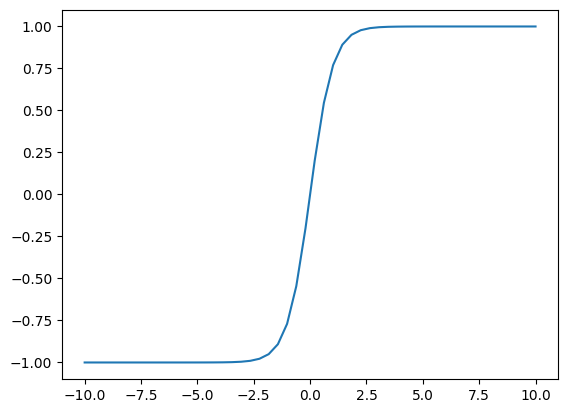

In [22]:
x=np.linspace(-10,10)
plt.plot(x, np.tanh(x))

# Модель PINN

In [23]:
#класс с самой моделью

class SomeModel(nn.Module):
    def __init__(self,
                input_size = 1, #кол-во входных данных
                nnodes = 30, #кол-во нейронов на скрытом слое
                output_size = 1, #кол-во выходных данных
                nlayers = 20, #кол-во скрытых слоев
                 activation=nn.Tanh(), #функция активации
                 ):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers-1)
        ])

        self.output_layer = nn.Linear(nnodes, 1)
        self.apply(self._init_weights_xavier) # ИНИЦИАЛИЗАЦИЯ ВЕСОВ


    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


    def forward(self, x):
        # написать передачу по слоям
        if x.dtype == torch.float64:
            x = x.float()
        x =self.activation(self.dense0(x))

        for layer in self.hidden_layers:
          x = self.activation(layer(x))
        x=self.output_layer(x)
        x = self.activation(x)
        return x

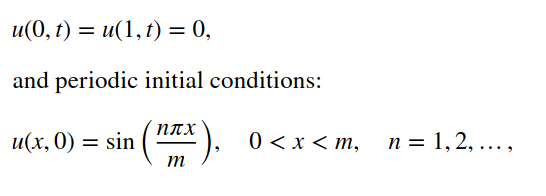

# Набор точек для граничного условия

Класс при инициализации принимает x, t -- входные точки.

*   Функция `flatten()` вытягивает входные массивы в столбцы.
*   Функция `torch.from_numpy` из numpy массива создает torch тензор.
*   `np.vstack` конкатинирует столбцы в один массив. Также необходимо, чтобы `grid`, т.е. то, что непосредственно подставляется в PINN, имела размер NxM, где N-кол-во точек, M-размерность задачи, в данном случае--2.
*   `torch.randperm` -- перемешивает индексы. Можно затем выбрать необходимое кол-во элементов.
*   `self.points.requires_grad` надо поставить `True`, чтобы рассчитывать производные

In [ ]:
class Batch_bc:
    def __init__(self, x, t, values):
        x =
        t =
        self.grid =
        self.u =

    def generate_points(self, N):
        indices = torch.randperm()
        self.points = self.grid
        self.values = self.u
        self.points.requires_grad=

# Набор точек во внутренней области

Класс при инициализации принимает x, t -- входные точки. Аналогично предыдущему классу. Но надо выбрать только внутреннюю область.

In [ ]:
class Batch:
    def __init__(self, data: Dataset):
        self.grid =
        self.u =

    def generate_points(self, N):
        indices = torch.randperm()
        self.points =
        self.values =
        self.points.requires_grad =

# PDE -- функция, которая возвращает невязки от уравнений

Необходимо расчитывать производные через автоматическое дифференцирование:
```
gradu = torch.autograd.grad(u, grid,
                                torch.ones_like(u),
                                create_graph=True, \
                            retain_graph=True)[0] #x, t
```
* u -- переменная, от которой берется производная.


*  grid -- массив, по которому берется производная, т.е.:

d u / d grid

* Третий аргумент должен быть единичной матричей по размеру первого аргументы. Более подробное объяснение: https://discuss.pytorch.org/t/what-is-the-grad-outputs-kwarg-in-autograd-grad/94378/4

* retain_graph=True, чтобы граф вычислений сохранился и использовался затем при вызове Backward при обуении.

* create_graph=True, чтобы можно было далее посчитать производную более высокого порядка для этой переменной.







In [ ]:
def PDE(u, grid, alpha):
    gradu =
    uxx =
    ut=
    #residuals -- невязка уравнения
    #(mse) между предсказанием и истинным значением.
    residuals=torch.mean(()**2)
    return residuals

# copyBCLoss -- функция для копирования граничного условия



*   out -- выход модели на сетке
*   loss -- так же, как и residuals -- СКЗ (mse) между предсказанием и истинным значением.



In [ ]:
def copyBCLoss(model, grid, sol):
    out=
    loss =
    return loss

# Параметры обучения

Необязательно делать в виде класса, но так удобнее передавать их в функцию одним классом, а не по отдельности. Плюс, это не глобальные переменные, разбросанные по всему коду.

In [ ]:
class TrainParams:
    def __init__(self):
        self.alpha=None # параметр в уравнении диффузии
        self.numEpoch=None # кол-во эпох в цикле обучения
        self.numPoints=None # размер батча для обучения во внутренней области
        self.batch=None # сам батч, class Batch
        self.init_bc=None  # батч для ГУ слева, class Batch_bc
        self.right_bc=None # батч для ГУ справа, class Batch_bc
        self.left_bc=None # сам батч для НУ, class Batch_bc
        self.numBCPoints=None # кол-во точек в батче для ГУ

# Функция residuals для расчета общего loss.

Loss здесь будет состоять из трех частей -- невязка от уравнений, отличие от ГУ и НУ.

Каждое слагаемое в Loss входит со своим весовым коэффициентом. Задайте коэффициент `k_bc=1e2`. Перед известными НУ и ГУ ставится всегда коэффициент больше, чтобы нейросеть быстрее их выучила.

In [ ]:
def residuals(model, trp: TrainParams):
    out=
    lossPDE=PDE()
    initBCLoss = copyBCLoss()
    rightBCLoss = copyBCLoss()
    leftBCLoss = copyBCLoss()
    k_bc=
    loss =
    return loss

# Train

Сама функция обучения.

`pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')`

Это строка для вывода значений loss.

В цикле вам необходимо генерировать точки для внутренней области, ГУ, НУ.

In [ ]:
def train(model, opt, scheduler, trPs: TrainParams):
    pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')
    for step in pbar:
        # сгенерировать точки для обучения

        def closure():
            #дописать функцию оптимизаторв
            opt.
            loss  =
            loss.
            return loss

        current_loss = opt.step
        # для накопления шага планировщика
        lrs.append(opt.param_groups[0]["lr"])
        # обновление шага
        scheduler.step()

        # сохранение истории Loss
        hist_loss.append()

        #логгирование
        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" %
                                 (step, current_loss))

    return 0

# Создание точек для обучения внутри области и для наччальных условий.

Визуализируйте график с помощью plt.scatter. В эту функцию передаются координаты точек, а окрасить их можно в цвет самих значений, это аргумент c (color).

Чтобы визуализировать данные, необходимо torch tensor вернуть в numpy массив на cpu:

`.detach().cpu().numpy()`

In [ ]:
# передайте нужные параметры
train_batch=Batch()

initial_bc=Batch_bc()
left_bc=Batch_bc()
right_bc=Batch_bc()

# сгенерируйте 500 внутренних точек и по 100 точек для ГУ и НУ
train_batch.generate_points()
initial_bc.generate_points()
left_bc.generate_points()
right_bc.generate_points()

# постройте график с помощью plt.scatter

fig, ax=plt.subplots(1, 2, figsize=(10, 5))

i=0
f=ax[i].scatter(,
            ,
            c=, cmap='jet')
plt.colorbar(f, ax=ax[i])

i=1
f=ax[i].scatter(,
            ,
            c=, cmap='jet')
plt.colorbar(f, ax=ax[i])

plt.tight_layout()
plt.show()

# Задание параметров обучения.

* alpha=0.3
* Кол-во внутренних точек: 200
* Кол-во граничных точек: 100
* Кол-во эпох: 1000

In [ ]:
trPs=TrainParams()
trPs.alpha=

trPs.batch=
trPs.init_bc=
trPs.right_bc=
trPs.left_bc=

trPs.numPoints=
trPs.numBCPoints=
trPs.numEpoch=

# Создание самой модели



*   кол-во нейронов: 10
*   кол-во скрытых слоев: 4
* функция активации: tanh
*   оптимизатор: SGD, lr=1
*   scheduler: LambdaLR, lambda1 -- 0.99**epoch
* lrs, hist_loss -- массивы для накопления значения шага обучения и Loss





In [ ]:
model=SomeModel().to(device)
opt=torch.optim.SGD()

lambda1 = lambda epoch:
scheduler =

lrs = []
hist_loss=[]

In [ ]:
train(model, opt, scheduler, trPs)

# Вывод графиков обучения и изменений шага обучения в логарифмическом масштабе

In [ ]:
fig, ax= plt.subplots(1,2)

i=0
ax[i].plot()
ax[i].set_xscale('log')
ax[i].set_yscale('log')

i=1
ax[i].plot()
ax[i].set_xscale('log')
ax[i].set_yscale('log')
plt.tight_layout()
plt.show()

# Предсказания модели

* выведите предсказания модели на первоначальной квадратной сетке

* сделайте .detach().cpu().numpy().reshape, то есть превратите массив в массив первоначального размера

In [ ]:
grid_pred =
pred = model().detach().cpu().numpy().reshape()


# Выведите точное решение, предсказанное значение, и их разность по модулю, нормированную на точное решение.

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

i=0
f=ax[i].pcolor()
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) solution')

i=1
f=ax[i].pcolor()
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) prediction')

i=2
f=ax[i].pcolor()
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('abs(pred-sol)')


plt.tight_layout()
plt.show()
